<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter08_%E1%84%90%E1%85%A6%E1%86%A8%E1%84%89%E1%85%B3%E1%84%90%E1%85%B3%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


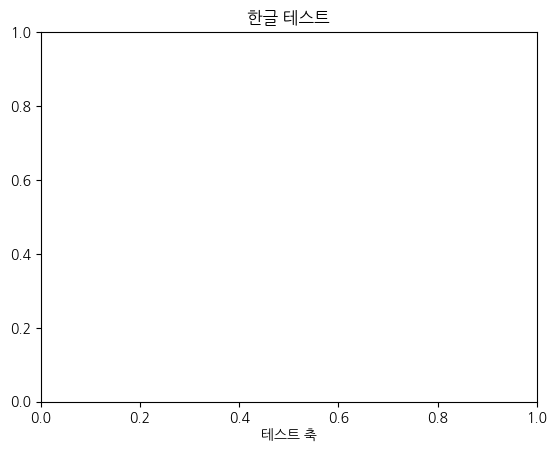

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm # 컬러맵(colormap)
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 토픽 모델링 (LDA)
-  LDA (Latent Dirichlet Allocation, 잠재 디리클레 할당)
- 문서 집합에서 숨겨진 주제(Topic)를 발견하는 비지도 학습
- 텍스트 마이닝에서 '문서들이 어떤 주제(Topic)를 가지고 있는가?'를 추론하는 가장 대표적인 알고리즘
- 핵심 가정:
1. 각 문서는 여러 토픽의 혼합으로 구성됨
2. 각 토픽은 특정 단어들이 자주 등장하는 확률 분포
- 레이블 없이 주제 구조 자동 발견
- LDA는 반드시 Count 벡터화 사용 (TF-IDF 사용 불가)
- 이유: LDA는 내부적으로 단어가 '몇 번' 등장했는지를 확률로 모델링


In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 8개 카테고리 뉴스그룹 데이터 로딩
cats = [
    'rec.motorcycles',      # 오토바이
    'rec.sport.baseball',   # 야구
    'comp.graphics',        # 컴퓨터 그래픽
    'comp.windows.x',       # 윈도우/X윈도우
    'talk.politics.mideast',# 중동 정치
    'soc.religion.christian',# 기독교
    'sci.electronics',      # 전자공학
    'sci.med'               # 의학
]
news_df = fetch_20newsgroups(
    subset = 'all', # 'train'+'test' 전체 사용
    remove = ('headers', 'footers', 'quotes'),
    categories=cats,
    random_state=0
)
print(f'데이터 크기: {len(news_df.data)}건')

데이터 크기: 7862건


In [ ]:
# CountVectorizer — LDA 전용 벡터화
count_vect = CountVectorizer(
    max_df=0.95, # 전체 문서의 95% 이상 등장 단어 제거, the, is 흔한 단어
    max_features=1000, #전체 어휘 중 상위 빈도 1000개만 사용
    min_df=2, # 2개 미만 문서에 등장하는 단어 제거, 오타, 희귀 단어
    stop_words='english', # 영어 불용어 제거
    ngram_range=(1, 2)  # 단어(1-gram) + 2연속단어(2-gram) 모두 피처로 사용
)
feat_vect = count_vect.fit_transform(news_df.data)
#어휘사전 구축 + 문서 → Count 행렬 변환, 희소 행렬 (문서 수 × 1000), CSR 저장 형식
print('CountVectorizer 행렬 shape:', feat_vect.shape)


CountVectorizer 행렬 shape: (7862, 1000)


In [ ]:
# LDA 모델 생성 및 학습
lda = LatentDirichletAllocation(
     n_components=8, # 토픽 수 = 실제 카테고리 수와 동일하게 설정
     random_state=0
)
lda.fit(feat_vect) #Count 행렬을 입력받아 각 토픽의 단어 분포 학습, LDA 내부 동작으로 비슷한 단어를 자주 쓰는 문서들이 같은 토픽으로 묶임


print('components_ shape:', lda.components_.shape)# lda.components_: (토픽수 × 단어수) 행렬
# 값: 해당 토픽에서 해당 단어가 나타날 '상대적 가중치', 값이 클수록 해당 토픽에서 더 중요한 단어
# components_[2, 50] = 3.5 # 토픽 2에서 어휘사전 50번 단어의 중요도가 3.5

components_ shape: (8, 1000)


In [ ]:
# 토픽별 핵심 단어 출력
def display_topics(model, feature_names, no_top_words):
  for topic_idx, topic in enumerate(model.components_): # 토픽 번호, 단어별 가중치 배열[3.5, 1.7, ...., 단어수 만큼]
    print(f'Topic #{topic_idx}')
    top_indexes = topic.argsort()[::-1][:no_top_words] # 내림차순 정렬, 0~14까지값의 인덱스 배열 반환
    feature_concat = ' '.join([feature_names[i] for i in top_indexes]) #인덱스로 실제 단어 이름 조회후 공백으로 연결
    print(feature_concat)

#어휘사전 단어 목록 추출
try:
  feature_names = count_vect.get_feature_names_out()
except AttributeError:
  feature_names = count_vect.get_feature_names()  # 구 버전 호환

#토픽별 상위 15개 핵심 단어 출력
display_topics(lda, feature_names, 15)

#각 도픽의 단어들을 보고 '이 토픽이 어떤 주제인지' 사람이 직접 해석

Topic #0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic #1
don just like know think good time ve does way really people want ll right
Topic #2
image file jpeg output program gif images format files color entry use bit 03 02
Topic #3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic #4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic #5
edu com available graphics ftp window use mail data motif software version pub information server
Topic #6
god people jesus church believe say christ does christian think christians did know bible man
Topic #7
thanks use using does help like display need problem know server screen windows window program


### 문서 군집화


In [ ]:
import pandas as pd
import glob, os

pd.set_option('display.max_colwidth', 700) #DataFrame 셀 내용을 최대 700자까지 표시

path = r'/content/drive/MyDrive/KWU/ML/Data/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path,'*.data')) #패턴에 맞는 모든 파일 경로를 리스트로 반환

filename_list = [] # 파일명
opinion_text  = [] # 파일 내용

for file_ in all_files:
  filename_ = os.path.basename(file_)   # 전체 경로에서 파일명만 추출
  filename  = filename_.split(' . ')[0] # 파일명 본체만 확장자 제거

  # 파일 내용 로딩
  df = pd.read_table(
      file_,
      index_col=None,     # 첫 열을 인덱스로 사용하지 않음
      header=0,           # 첫 행을 컬럼명으로 사용
      encoding='latin1'
  )
  filename_list.append(filename)
  opinion_text.append(df.to_string()) # DataFrame 전체를 하나의 문자열로 변환,
                                      # 파일 내 모든 리뷰 문장을 하나의 텍스트 덩어리로 합침

document_df = pd.DataFrame({
    'filename':  filename_list,
    'opinion_text': opinion_text
})

print('로딩된 문서 수:', len(document_df))
document_df.head(3)

로딩된 문서 수: 51


,filename,opinion_text
0,navigation_amazon_kindle.txt.data,"In fact, the entire navigation structure has been completely revised , I'm still getting used to it but it's a huge step forward .\n0 ..."
1,comfort_toyota_camry_2007.txt.data,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n0 Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# .\n1 Great gas mileage and comfortable on long trips ..."
2,interior_toyota_camry_2007.txt.data,"First of all, the interior has way too many cheap plastic parts like the cheap plastic center piece that houses the clock .\n0 3 blown struts at 30,000 miles, interior trim coming loose and rattling squeaking, stains on paint, and bug splats taking paint off, premature uneven brake wear, on 3rd windsh..."


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.stem import WordNetLemmatizer
import string
lemmar = WordNetLemmatizer()

# 커스텀 Lemmatization 토크나이저 정의
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# 구두점 제거용 변환 테이블 생성
# string.punctuation: '!'#$%&\'()*+,-./:;<=>?@[\]^_`{|}~' 구두점 문자열
remove_punct_dict = {
    ord(punct): None for punct in string.punctuation
      # ord(punct) : 구두점 문자의 유니코드 정수값
}
# str.translate()에서 해당 문자를 None(삭제)으로 치환

def LemNormalize(text):
  return LemTokens(
      nltk.word_tokenize(
          text.lower().translate(remove_punct_dict)
      )
  )

print('예시:', LemNormalize('Hotels are providing excellent servicies.'))

예시: ['hotel', 'are', 'providing', 'excellent', 'servicies']


In [ ]:
# TF-IDF 벡터화 + KMeans 문서 군집화
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf_vect      = TfidfVectorizer(
    tokenizer   = LemNormalize,   # 커스텀 함수 사용
    stop_words  = 'english',
    ngram_range = (1, 2),
    min_df      = 0.05,           # 전체 문서의 5% 이상 등장 단어만 사용
    max_df      = 0.85            # 전체 문서의 85% 이하 등장 단어만 사용
)
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
print('TF-IDF 행렬 shape:', feature_vect.shape)


TF-IDF 행렬 shape: (51, 4610)


In [ ]:
km_cluster = KMeans(
    n_clusters=3,
    max_iter=10000,
    random_state=0
)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
document_df['cluster_label'] = cluster_label
print('\n군집별 문서 분포:')
print(document_df['cluster_label'].value_counts().sort_index())


군집별 문서 분포:
cluster_label
0    16
1     7
2    28
Name: count, dtype: int64


In [ ]:
# 군집별 문서(파일명) 확인
for cl in range(3):
  files = document_df[document_df['cluster_label'] == cl]['filename'].values
  print(f'\n Cluster {cl} ({len(files)}개 문서)')
  print(sorted(files))


 Cluster 0 (16개 문서)
['bathroom_bestwestern_hotel_sfo.txt.data', 'food_holiday_inn_london.txt.data', 'food_swissotel_chicago.txt.data', 'free_bestwestern_hotel_sfo.txt.data', 'location_bestwestern_hotel_sfo.txt.data', 'location_holiday_inn_london.txt.data', 'parking_bestwestern_hotel_sfo.txt.data', 'price_holiday_inn_london.txt.data', 'room_holiday_inn_london.txt.data', 'rooms_bestwestern_hotel_sfo.txt.data', 'rooms_swissotel_chicago.txt.data', 'service_bestwestern_hotel_sfo.txt.data', 'service_holiday_inn_london.txt.data', 'service_swissotel_hotel_chicago.txt.data', 'staff_bestwestern_hotel_sfo.txt.data', 'staff_swissotel_chicago.txt.data']

 Cluster 1 (7개 문서)
['buttons_amazon_kindle.txt.data', 'directions_garmin_nuvi_255W_gps.txt.data', 'display_garmin_nuvi_255W_gps.txt.data', 'eyesight-issues_amazon_kindle.txt.data', 'fonts_amazon_kindle.txt.data', 'navigation_amazon_kindle.txt.data', 'price_amazon_kindle.txt.data']

 Cluster 2 (28개 문서)
['accuracy_garmin_nuvi_255W_gps.txt.data', 'ba

In [ ]:
#군집별 핵심 단어 추출
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num, top_n_features=10):
  cluster_details = {}
  #군집 중심점 기준 단어별 TF-IDF 값 내림차순 인덱스
  centroid_ordered = cluster_model.cluster_centers_.argsort()[:,::-1] #cluster_centers_: (군집수 × 단어수)행렬, 각 행 = 해당 군집 중심점의 TF-IDF 값 백터
  for cluster_num in range(clusters_num):
    cluster_details[cluster_num] = {'cluster':cluster_num}
    #상위 top_n_features개 핵심 단어 인덱스 추출
    top_idxs = centroid_ordered[cluster_num,:top_n_features] #centroid_ordered[i,j]: 군집 i에서 j번째로 중요한 단어의 인덱스
    top_words = [feature_names[i] for i in top_idxs] #인덱스 -> 실제 단어 이름으로 변환

    top_values = cluster_model.cluster_centers_[
        cluster_num, top_idxs
    ].tolist() #numpy배열 -> 파이썬 리스트 변환

    cluster_details[cluster_num]['top_features'] = top_words #핵슴 단어들
    cluster_details[cluster_num]['top_features_value'] = top_values #실제 TF-IDF 중심 값

    #해당 군집에 속하는 파일명 목록
    filenames = cluster_data[
        cluster_data['cluster_label'] == cluster_num
    ]['filename'].values.tolist()
    cluster_details[cluster_num]['filenames'] = filenames

  return cluster_details

#어휘 사전 추출 (버전 호환)
try:
  feature_names = tfidf_vect.get_feature_names_out()
except:
  feature_names = tfidf_vect.get_feature_names()

cluster_details = get_cluster_details(
    cluster_model=km_cluster,
    cluster_data=document_df,
    feature_names=feature_names,
    clusters_num=3,
    top_n_features=10
)

def print_cluster_details(cluster_details):
  #군집별 핵심 단어와 파일명 출력
  for num,detail in cluster_details.items():
    print(f'\nCluster{num}')
    print('Top features:',detail['top_features'])
    print('Reviews 파일명:',detail['filenames'][:7])
print_cluster_details(cluster_details)


Cluster0
Top features: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'bathroom', 'clean', 'price', 'parking']
Reviews 파일명: ['location_holiday_inn_london.txt.data', 'rooms_swissotel_chicago.txt.data', 'rooms_bestwestern_hotel_sfo.txt.data', 'staff_swissotel_chicago.txt.data', 'room_holiday_inn_london.txt.data', 'bathroom_bestwestern_hotel_sfo.txt.data', 'service_holiday_inn_london.txt.data']

Cluster1
Top features: ['kindle', 'page', 'button', 'font', 'direction', 'book', 'eye', 'display', 'navigation', 'price']
Reviews 파일명: ['navigation_amazon_kindle.txt.data', 'display_garmin_nuvi_255W_gps.txt.data', 'directions_garmin_nuvi_255W_gps.txt.data', 'eyesight-issues_amazon_kindle.txt.data', 'price_amazon_kindle.txt.data', 'fonts_amazon_kindle.txt.data', 'buttons_amazon_kindle.txt.data']

Cluster2
Top features: ['battery', 'screen', 'interior', 'seat', 'performance', 'mileage', 'battery life', 'life', 'keyboard', 'comfortable']
Reviews 파일명: ['comfort_toyota_camry_2007.txt.data',